In [1]:
import pandas as pd  
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RepeatedKFold, KFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer 


El objetivo es predecir el diagnóstico de un paciente a partir de tres variables siológicas.
Variables:
* glucose concentración de glucosa en plasma
* insulin concentración de insulina
* sspg steady state plasma glucose
* class diagnóstico (Normal, Chemical, Overt)

In [2]:
df = pd.read_csv("../data/diabetes.csv")

In [3]:
df.head(2)

,class,glucose,insulin,sspg
0,Normal,80,356,124
1,Normal,97,289,117


# 1. Realice un análisis exploratorio del conjunto de datos


a) Calcule estadísticas descriptivas de las variables.


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
glucose,145.0,121.986207,63.930408,70.0,90.0,97.0,112.0,353.0
insulin,145.0,540.786207,319.564964,45.0,352.0,403.0,558.0,1568.0
sspg,145.0,186.117241,120.935158,10.0,118.0,156.0,221.0,748.0


Imprimimos las estadísticas más descriptivas de los datos, podemos ver que la media de la glucosa es 121 la insulina tiene una media de 540 y y la glucosa en la sangre tiene una media de 145, usualmente tanto la glucosa como la sspg en la sangre tienen más o menos el mismo rango sin en cambio la insulina posee rangos más variados por lo que a primera vista se ve que necesitamos una normalización de los datos para que entren en el mismo rango y realizar correctamente la clasificación

In [5]:
df['class'].value_counts(normalize=True)*100

class
Normal      52.413793
Chemical    24.827586
Overt       22.758621
Name: proportion, dtype: float64

Ahora veamos cómo se distribuyen nuestros datos notemos que la mayor cantidad de estos se encuentran en gente normal con más del 52% de los datos química con un 25% y con over con 22%. 
Si bien nuestros datos están desbalanceados no existe un desbalanceo significante por lo que podemos entrenar un modelo usando los datos que tenemos.

b) Grafique las distribuciones de glucose, insulin y sspg.

El siguiente gráfico muestra las distribuciones de cada una de las variables que estamos midiendo podemos notar que la mayoría de la gente posee un nivel de glucosa de aproximadamente 80 a 130, el nivel de insulina normal se encuentra en un rango de 300 a 500, mientras que el nivel de sspg está en un rango normal de 100 a 200

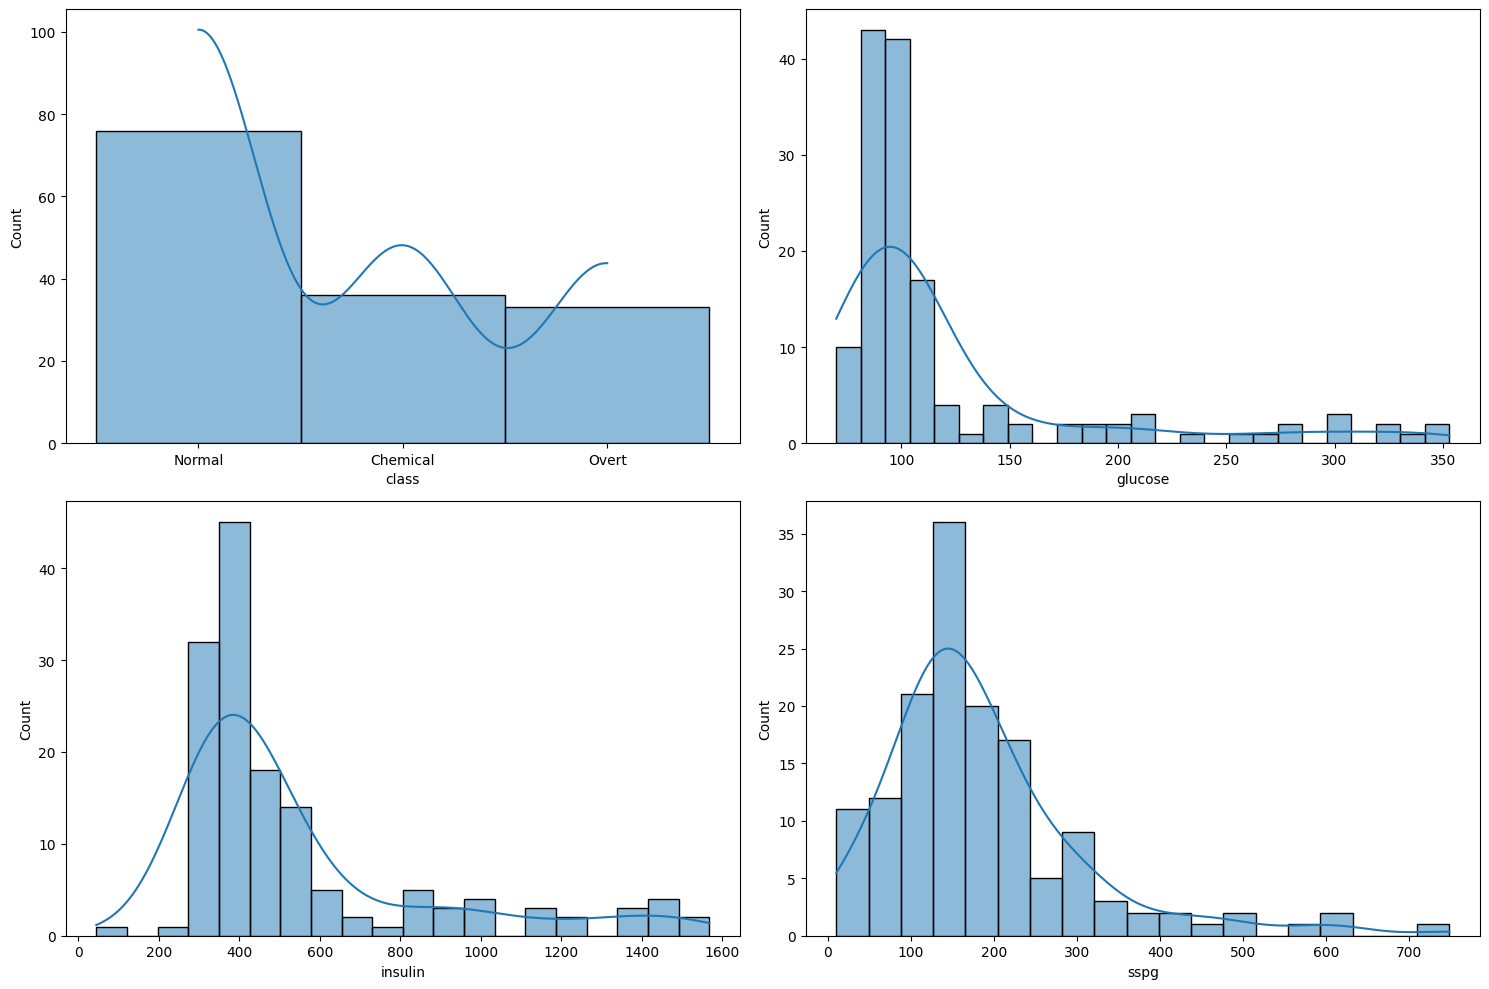

In [6]:

fig, ax = plt.subplots(figsize=(15, 10), ncols=2, nrows=2)

for i, col in enumerate(df.columns):
    sns.histplot(df[col], ax = ax[i//2][i%2], kde=True, edgecolor="black")
plt.tight_layout()
plt.show()


c) Compare las distribuciones entre pacientes los distinstos tipos de pacientes (Normal, Chemical, Overt)

Exception in callback BaseAsyncIOLoop._handle_events(1452, 1)
handle: <Handle BaseAsyncIOLoop._handle_events(1452, 1)>
Traceback (most recent call last):
  File "C:\Users\Axel MG\AppData\Local\Programs\Python\Python312\Lib\asyncio\events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
  File "d:\Supply Chain Resilience\venv\Lib\site-packages\tornado\platform\asyncio.py", line 208, in _handle_events
    handler_func(fileobj, events)
  File "d:\Supply Chain Resilience\venv\Lib\site-packages\zmq\eventloop\zmqstream.py", line 600, in _handle_events
    self._handle_recv()
  File "d:\Supply Chain Resilience\venv\Lib\site-packages\zmq\eventloop\zmqstream.py", line 629, in _handle_recv
    self._run_callback(callback, msg)
  File "d:\Supply Chain Resilience\venv\Lib\site-packages\zmq\eventloop\zmqstream.py", line 550, in _run_callback
    f = callback(*args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\Supply Chain Resilience\venv\Lib\site-packages\ipykernel

<Axes: xlabel='class', ylabel='glucose'>

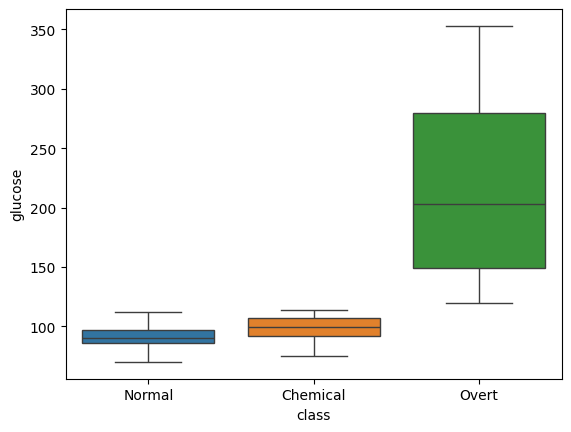

In [7]:
sns.boxplot(y='glucose', x='class', data=df, hue='class')


Al graficar el boxplot entre la clase y la glucosa podemos notar que existe una diferencia significativa entre los datos normal y chemical con los de la clase overt. 
Sin embargo entre las clases normal y chemical no existe una gran diferencia significativa

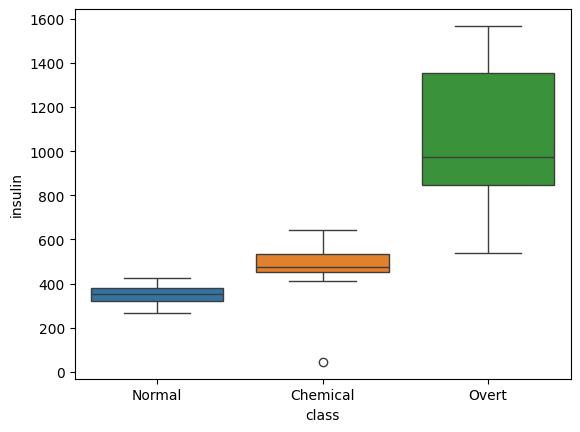

In [8]:
sns.boxplot(y='insulin', x='class', data=df, hue='class')
plt.show()

De la misma forma podemos notar que sí existen diferencias entre los cuartiles de las 3 clases   pero no alcanzamos a detectar valores atípicos

<Axes: xlabel='class', ylabel='sspg'>

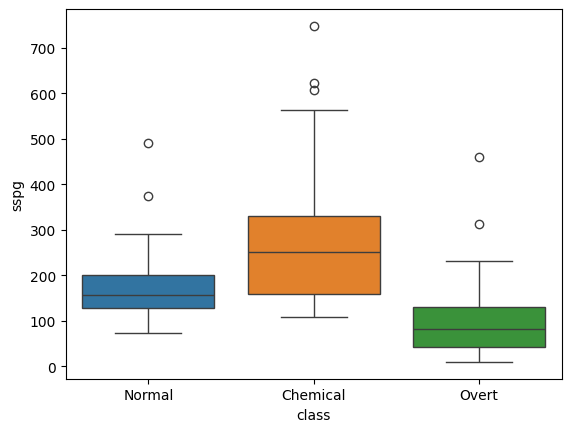

In [9]:
sns.boxplot(y='sspg', x='class', data=df, hue='class')


Por último analicemos un pairplot.

Podemos observar que nuestras variables insulina y glucosa tienen cierta relación positiva, es decir a medida que aumentalos la insulina, aumenta la glucosa.

Por otra parte, sspg con glucosa tienen una relación negativa

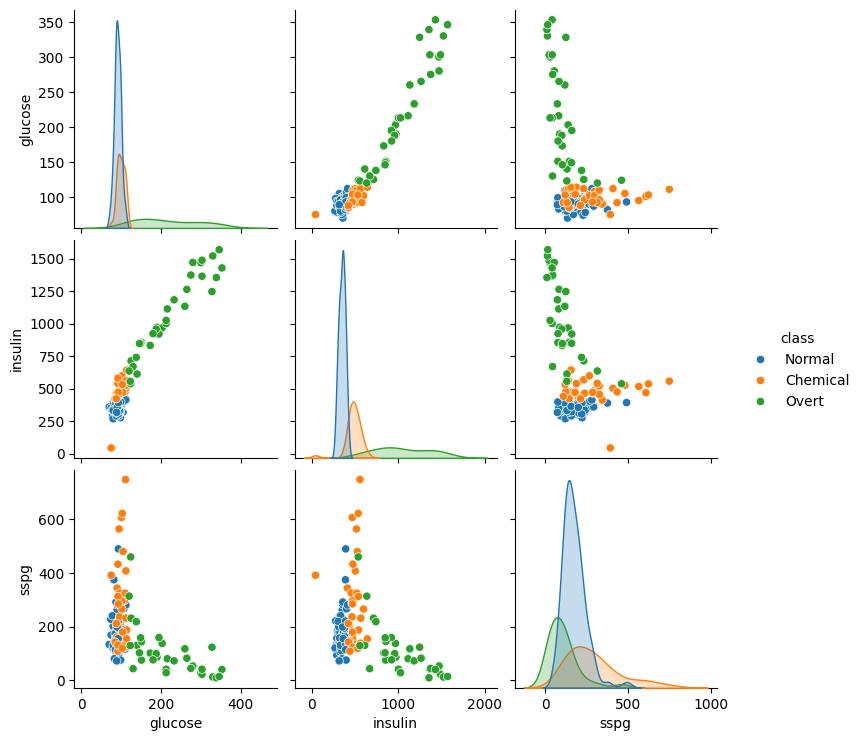

In [10]:
sns.pairplot(df, hue='class', diag_kind='kde')

# 2. Explica por qué es necesario escalar las variables cuando se utiliza el algoritmo KNN.
a) Estandarice las variables predictoras

b) Divida los datos en conjunto de entrenamiento y prueba (80-20)

c) Qué ocurriría si no se escalan las variables.

In [11]:
X = df.drop('class', axis=1)
y = df['class']
col_num = X.select_dtypes(include='number').columns
column_transformer = ColumnTransformer([('scaler', StandardScaler(), col_num)])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Si no estandarizamos las variables probablemente nuestro modelo tendría una pérdida de precisión bastante considerable y le daría mayor importancia a una característica que tenga un rango más amplio. 

Al estandarizar los datos aseguramos que el espacio en donde se encuentran nuestros datos estén en la misma escala haciendo que le dé igual importancia a cada una de las características del modelo puesto que knn se basa en métricas de distancias en este caso en la distancia euclidiana

# 3. Emplea el algoritmo KNN(k) para valores de k = 1,3,5,7,9,11.

Utiliza una validación cruzada de 10-folds

a) calcule la exactitud promedio

b) grafique la exactitud en función de k

In [12]:
from sklearn.pipeline import make_pipeline

espacio_parametral = {
    "kneighborsclassifier__n_neighbors": [1,3,5,7,9,11]
}

pipeline = make_pipeline(column_transformer, KNeighborsClassifier())
dis_validacion = RepeatedKFold(n_splits=10, n_repeats=5, random_state=42)

grid_search = GridSearchCV(pipeline,
                           param_grid=espacio_parametral,
                           cv=dis_validacion,
                           scoring= "accuracy",                           
                           n_jobs=-1)
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'kneighborsclassifier__n_neighbors': [1, 3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",RepeatedKFold...ndom_state=42)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the sco

In [13]:

results = pd.DataFrame(grid_search.cv_results_)
ks = espacio_parametral["kneighborsclassifier__n_neighbors"]
accuracy_vals = results['mean_test_score']

In [14]:
mejor_k = list((grid_search.best_params_).values())[0]
print(f"Mejor k: {mejor_k} con accuracy: {grid_search.best_score_:.4f}")


Mejor k: 1 con accuracy: 0.8835


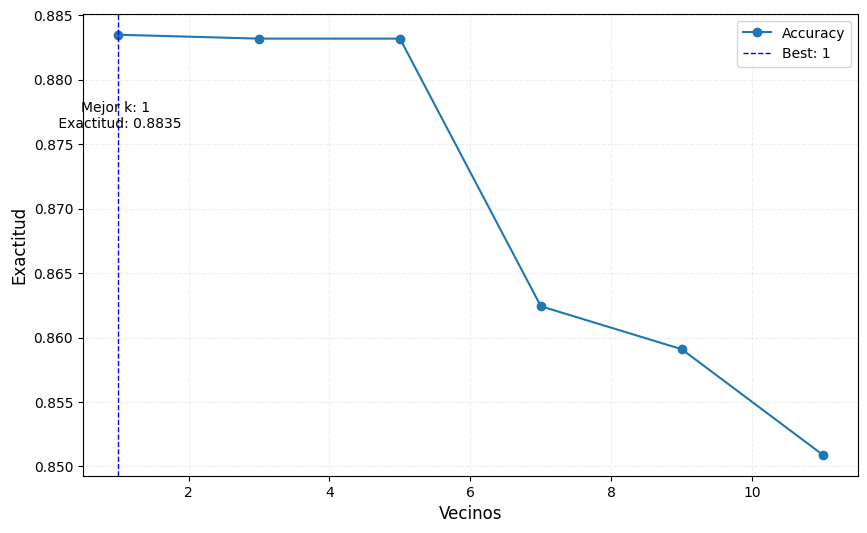

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(ks, accuracy_vals, marker='o', linestyle='-', label='Accuracy')
plt.axvline(mejor_k, color='blue', linestyle='--', linewidth=1, label=f'Best: {mejor_k}')
plt.text(mejor_k, plt.ylim()[1]*0.99, f'Mejor k: {mejor_k} \n Exactitud: {grid_search.best_score_:.4f}', color='black', fontsize=10, ha='center')
plt.xlabel("Vecinos", fontsize=12) 
plt.ylabel("Exactitud", fontsize=12)
plt.grid( linestyle="--", alpha=0.2)
plt.legend()
plt.show()

# 4. Explica el comportamiento observado en la gráfica obtenida en el ejercicio 3 en términos del trade-o sesgo-varianza.
 * Qué ocurre cuando k es muy pequeño?
 * qué ocurre cuando k es muy grande?
 * cómo se relaciona esto con el sobreajuste?

Notemos que conforme el número de vecinos k es menor, mayor exactitud tiene el modelo en la validación.

Esto indica que el modelo tiene una alta varianza y un bajo sesgo pero también es más complejo para separar las clases de los pacientes y esto probablemente pueda derivar en sobreajuste. 

Por otra parte al aumentar el valor de k el sesgo aumenta y la exactitud disminuye estamos realizando un modelo más simple pero no es capaz de capturar la estructura de los datos completos y podríamos llevar a un sobre ajuste lo ideal es considerar un modelo intermedio con un k intermedio para evitar tanto el sobre ajuste como el subajuste

# 5. Seleccione el valor óptimo de k y entrene el modelo final.
Calcule en el conjunto de prueba:
 - matriz de confusión
 - exactitud

In [16]:

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, ConfusionMatrixDisplay

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Chemical       0.88      1.00      0.93         7
      Normal       1.00      0.93      0.97        15
       Overt       1.00      1.00      1.00         7

    accuracy                           0.97        29
   macro avg       0.96      0.98      0.97        29
weighted avg       0.97      0.97      0.97        29



Text(0.5, 1.0, 'Matriz de Confusión')

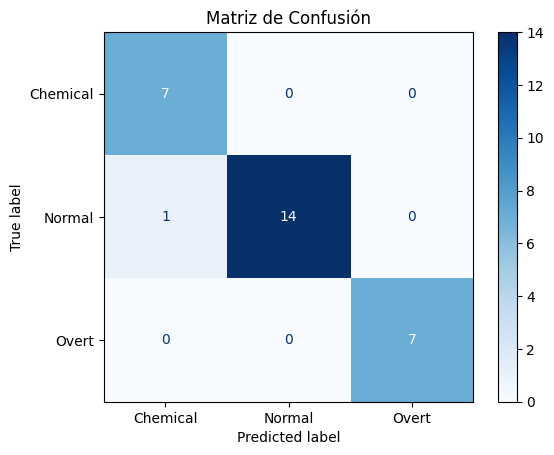

In [17]:
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, display_labels=best_model.classes_, cmap=plt.cm.Blues)
plt.title("Matriz de Confusión")

In [18]:
print(f'La exactitud para el conjunto de prueba es: {accuracy_score(y_test, y_pred):.3f}')

La exactitud para el conjunto de prueba es: 0.966


# 6. Implemente validación cruzada anidada para seleccionar el valor óptimo de k
Compare:
* la exactitud obtenida con validación simple
* la obtenida mediante validación cruzada simple con validación cruzada anidada.
* por qué la validación anidada produce una estimación más confiable

In [19]:
cv_externa = KFold(n_splits=5, shuffle=True, random_state=42)
cros_val_anidada = cross_val_score(
    grid_search,      
    X_train,
    y_train, 
    cv=cv_externa, 
    scoring='accuracy',
    n_jobs=-1
)

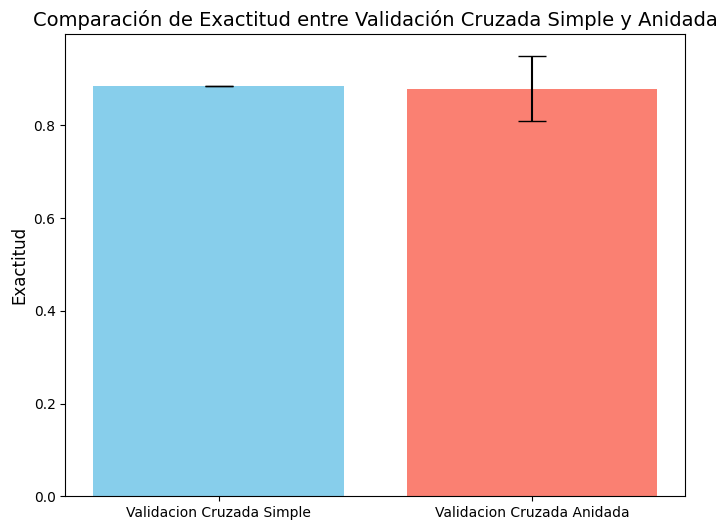

In [20]:
accuracy_simple = grid_search.best_score_
accuracy_anidada = cros_val_anidada.mean()
deviation_standard_anidada = cros_val_anidada.std()


etiquetas = ['Validacion Cruzada Simple', 'Validacion Cruzada Anidada']
valores=[accuracy_simple, accuracy_anidada]
desviaciones = [0, deviation_standard_anidada]


plt.figure(figsize=(8, 6))
plt.bar(etiquetas, valores, yerr=desviaciones, capsize=10, color=['skyblue', 'salmon'])
plt.ylabel('Exactitud', fontsize=12)
plt.title('Comparación de Exactitud entre Validación Cruzada Simple y Anidada', fontsize=14)
plt.show()


La validación cruzada anidada es más confiable porque estamos evitando el problema de la fuga de información.

Mediante el bucle externo nos estamos encargando de evaluar el modelo con datos que nunca antes había visto sin embargo en la validación cruzada simple con nuestros mismos datos estamos entrenando y validando el modelo lo que puede llevar a una fuga de información. 
Esto nos ayuda con el problema de sobreajuste y a la eleccion del modelo que mas se adapte a nuestros datos lo que nos lleva directamente a un mejor modelo a la hora de la generalizacion

# 7. Con el modelo óptimo entrenado, realiza las predicciones en los siguientes pacientes:

In [21]:
glucose = [98, 108, 130, 100]
insulin = [325, 485, 670, 277]
sspg = [114, 697, 100, 221]

In [25]:
X_new = pd.DataFrame({'glucose': glucose, 'insulin': insulin, 'sspg': sspg})
X_new

,glucose,insulin,sspg
0,98,325,114
1,108,485,697
2,130,670,100
3,100,277,221


In [26]:
y_new_pred = best_model.predict(X_new)
print("Predicciones para los nuevos datos:", y_new_pred)

Predicciones para los nuevos datos: ['Normal' 'Chemical' 'Overt' 'Normal']
